## Polynomial Regression Model

In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

# Replace 'your_file.csv' with the path to your CSV file
file_path = 'movies_output_clean.csv'

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

df_first = df[['Director', 'RottenTomatoesScore (%)', 'BoxOfficeEarnings ($)', 'IMDbRating']] 
#df_first.loc[:, 'Sqrt Box Office'] = np.sqrt(df_first['BoxOfficeEarnings ($)'])

df_drops = df_first.dropna()
# After dropping instances of we are left with 732 movie

df_drops

,Director,RottenTomatoesScore (%),BoxOfficeEarnings ($),IMDbRating
1,Damien Leone,77.0,45670161.0,6.7
2,Chris Sanders,98.0,137913995.0,8.3
3,Tim Miller,85.0,363070709.0,8.0
4,Parker Finn,85.0,41787385.0,7.2
5,Coralie Fargeat,90.0,16235191.0,7.5
...,...,...,...,...
995,Doug Liman,60.0,186336279.0,6.5
996,Rawson Marshall Thurber,71.0,127440871.0,6.3
997,Tom Shadyac,47.0,72217396.0,6.9
998,Brad Bird,49.0,93436322.0,6.4


In [36]:
df_new = df_drops[['Director', 'BoxOfficeEarnings ($)']]  

df_wo_na = df_new.dropna() 

df_wo_na.head(12)

,Director,BoxOfficeEarnings ($)
1,Damien Leone,45670161.0
2,Chris Sanders,137913995.0
3,Tim Miller,363070709.0
4,Parker Finn,41787385.0
5,Coralie Fargeat,16235191.0
6,Josh Cooley,58023121.0
8,Fede Alvarez,105309610.0
10,"Chris Renaud, Patrick Delage",361004205.0
11,Kelsey Mann,652980194.0
14,Ruben Fleischer,213515506.0


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df_final = df_wo_na.copy() 
df_final['Director'] = df_final['Director'].str.split(',').str[0].str.strip()

# One-hot encoding
df_encoded = pd.get_dummies(df_final, columns=['Director'], prefix=['Director'])
df_encoded = df_encoded.loc[df_final.index]

# Scaling data
scaler = StandardScaler()
X = scaler.fit_transform(df_encoded)

# Polynomial features
poly = PolynomialFeatures(2)
X_poly = poly.fit_transform(X)

y = df_final['BoxOfficeEarnings ($)']

Xtrain, Xtest, ytrain, ytest = train_test_split(X_poly, y, test_size = 0.3, random_state = 0)

# Model Training
model = LinearRegression()
model.fit(Xtrain, ytrain)

# Predictions
y_pred = model.predict(Xtest)

residuals = ytest - y_pred

# Evaluation
mse = mean_squared_error(ytest, y_pred)
r2 = r2_score(ytest, y_pred)

print(f"MSE: {mse}")
print(f"R²: {r2}")

MSE: 1.784116518342624e+16
R²: 0.03929193220911842


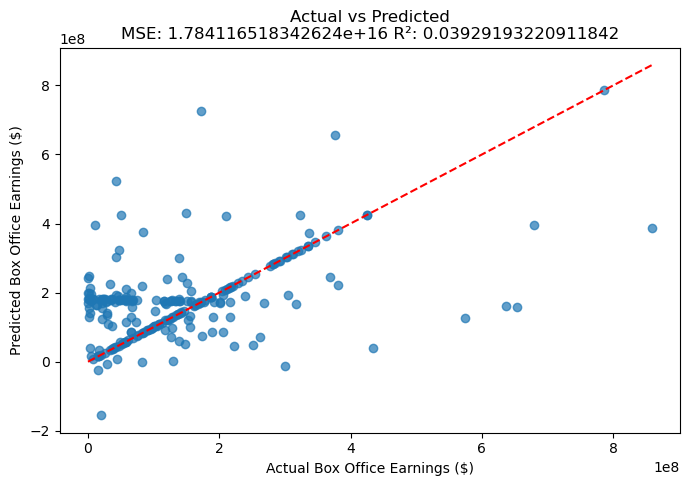

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot
import pandas as pd
 
# Linearity: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(ytest, y_pred, alpha=0.7)
plt.plot([min(ytest), max(ytest)], [min(ytest), max(ytest)], color='red', linestyle='--')
plt.title('Actual vs Predicted\nMSE: 1.784116518342624e+16 R²: 0.03929193220911842' )
plt.xlabel('Actual Box Office Earnings ($)')
plt.ylabel('Predicted Box Office Earnings ($)')
plt.show()

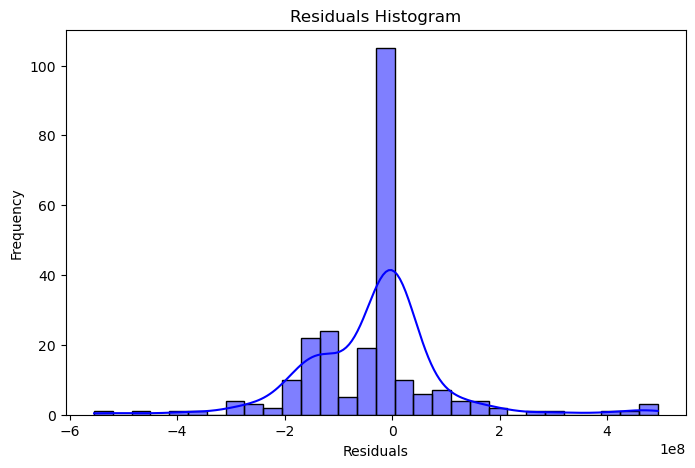

In [42]:
# Normality of Residuals: Histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

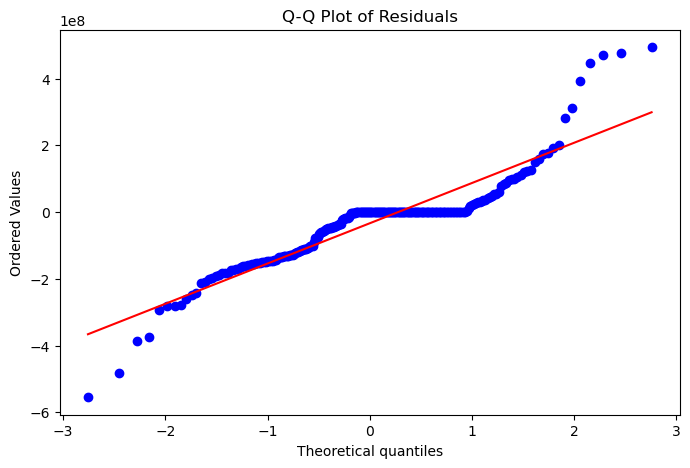

In [44]:
# Normality of Residuals: Q-Q Plot
plt.figure(figsize=(8, 5))
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

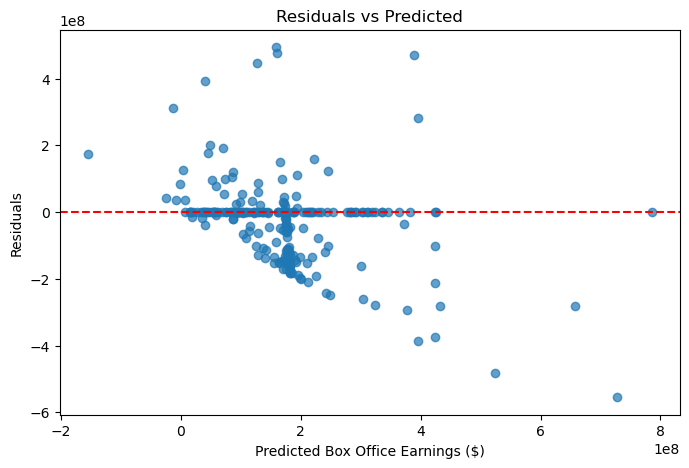

In [46]:
# Homoscedasticity: Residuals vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Box Office Earnings ($)')
plt.ylabel('Residuals')
plt.show()